# Pima Indians Diabetes Dataset 
## Classificazione Binaria per predizione del rischio di diabete sulla base di misure cliniche facilmente rilevabili.

*Aurora Loprino* - aurora.loprino@studio.unibo.it


# 1. Introduzione del problema
## Predizione del Rischio di Diabete

Il diabete mellito di tipo 2 è una delle malattie croniche più diffuse al mondo. 
Secondo l'OMS, più di 422 milioni di persone ne sono affette e il numero è in continua crescita.
(WHO, Global Report on Diabetes, 2016 - https://www.who.int/publications/i/item/9789241565257)

Una diagnosi precoce è fondamentale per rallentare la progressione della malattia e ridurre le complicanze da lei causata, quali neuropatia, retinopatia e malattie cardiovascolari.

Questo progetto si pone di costruire un modello di classificazione capace di prevedere se un paziente è a rischio di diabete sulla base di misure cliniche facilmente rilevabili. Un sistema di questo tipo potrebbe supportare i medici di base nello screening preventivo, consentendo di identificare pazienti a rischio prima che sviluppino sintomi conclamati.

Tipo di task: classificazione binaria
- Classe 0: paziente non diabetico
- Classe 1: paziente diabetico

# 2. Descrizione del dataset

Il dataset utilizzato è il **Pima Indians Diabetes Dataset**, originariamente raccolto dal *National Institute of Diabetes and Digestive and Kidney Diseases* e reso pubblico da Smith et al. (1988).

Per questo progetto il dataset è stato recuperato da Github: https://gist.github.com/ktisha/c21e73a1bd1700294ef790c56c8aec1f

E' anche disponibile su Kaggle: https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset, però è diventato difficile da reperire in maniera affidabile.

Tra le variabili abbiamo:
* **Pregnancies** - Numero di gravidanze 
* **Glucose** - Concentrazione di glucosio nel plasma (mg/dL) dopo test di tolleranza 
* **BloodPressure** - Pressione diastolica (mm Hg) 
* **SkinThickness** - Spessore della piega cutanea del tricipite (mm) 
* **Insulin** - Livello di insulina a 2 ore (mu U/ml) 
* **BMI** - Indice di massa corporea (kg/m²) 
* **DiabetesPedigreeFunction** - Funzione che stima la predisposizione genetica al diabete 
* **Age** - Età in anni
* **Outcome** - Se 0 = non diabetico, altrimenti 1 = diabetico 

E' un dataset di 768 righe × 9 colonne e tutte le pazienti sono donne di almeno 21 anni di etnia Pima (nativi americani dell'Arizona), una popolazione storicamente ad alto rischio di diabete di tipo 2.

# 3. Lettura e preparazione dei dati




Importo le librerie, test e modelli.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

Carico il dataset e lo pulisco dai commenti, affinchè non appaiano

In [5]:
df = pd.read_csv(
    'Dataset/pima-indians-diabetes.csv',
    comment='#',
    header=None,
    names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']
)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Ora controllo i tipi di dato, verificando che tutte le colonne siano numeriche.

In [6]:
print('Tipi di dato:')
print(df.dtypes)

Tipi di dato:
Pregnancies           int64
Glucose               int64
BloodPressure         int64
SkinThickness         int64
Insulin               int64
BMI                 float64
DiabetesPedigree    float64
Age                   int64
Outcome               int64
dtype: object


Il dataset mostra dei valori 0, cioè dati mancanti. 
Vado a contare quanti zeri ci sono per ogni colonna biologicamente impossibile.

(Es. la glicemia NON può essere 0.)

In [7]:
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Conteggio zeri per variabile:')
for col in zero_features:
    n = (df[col] == 0).sum()
    print(f'{col}: {n} ({n/len(df)*100:.1f}%)')


Conteggio zeri per variabile:
Glucose: 5 (0.7%)
BloodPressure: 35 (4.6%)
SkinThickness: 227 (29.6%)
Insulin: 374 (48.7%)
BMI: 11 (1.4%)


Converto gli zero a NaN affinchè pandas possa gestire meglio i dati.

In [8]:
df_clean = df.copy()
df_clean[zero_features] = df_clean[zero_features].replace(0, np.nan)

print('Valori mancanti dopo sostituzione:')
print(df_clean.isnull().sum())

Valori mancanti dopo sostituzione:
Pregnancies           0
Glucose               5
BloodPressure        35
SkinThickness       227
Insulin             374
BMI                  11
DiabetesPedigree      0
Age                   0
Outcome               0
dtype: int64


Faccio uno split train/test prima dell'imputing, poi calcolo le mediane sul set allenato e lo applico su train e test per evitare il data leakage.
In questo modo il test set non influenza in nessun modo la preparazione dei dati di training, simulando correttamente il comportamento su dati nuovi.

Nota: rispetto alla versione precedente, non uso più la variabile Outcome per stratificare l'imputing.
Non sarebbe applicabile in produzione dove l'etichetta non è disponibile.


In [20]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
mediane_train = X_train[zero_features].median()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[zero_features] = X_train[zero_features].fillna(mediane_train)
X_test[zero_features] = X_test[zero_features].fillna(mediane_train)

print("Valori mancanti in X_train:", X_train.isnull().sum().sum())
print("Valori mancanti in X_test:", X_test.isnull().sum().sum())
print(f"\nDimensioni: train={X_train.shape}, test={X_test.shape}")


Valori mancanti in X_train: 0
Valori mancanti in X_test: 0

Dimensioni: train=(614, 8), test=(154, 8)


# 4. Visualizzazione ed EDA

Ora vado ad esplorare le caratteristiche del dataset attraverso statistiche descrittive e visualizzazioni, con l'obiettivo di comprendere le distribuzioni, le relazioni tra feature e target, e i potenziali problemi, quali sbilanciamento delle classi, outlier e correlazioni.


Mostro media, deviazione standard, min, max e quartili per ogni colonna.

In [10]:
df_clean.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
count,768.00,763.00,733.00,541.00,394.00,757.00,768.00,768.00,768.00
mean,3.85,121.69,72.41,29.15,155.55,32.46,0.47,33.24,0.35
std,3.37,30.54,12.38,10.48,118.78,6.92,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.00,64.00,22.00,76.25,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00,0.00
75%,6.00,141.00,80.00,36.00,190.00,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Poi vado a mostrare lo sbilanciamento tra classi e la distribuzione tra il target.

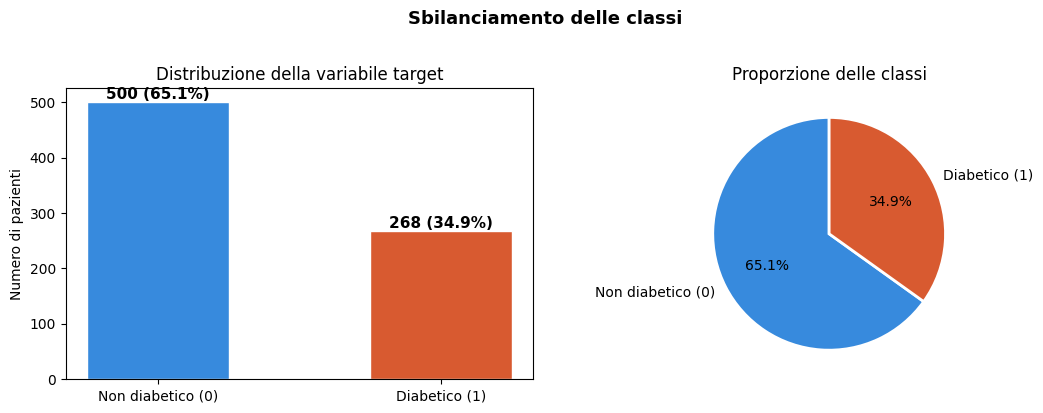

Non diabetici: 500 (65.1%)
Diabetici:     268 (34.9%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df_clean['Outcome'].value_counts().sort_index()
labels = ['Non diabetico (0)', 'Diabetico (1)']
colors = ['#378ADD', '#D85A30']

axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Distribuzione della variabile target')
axes[0].set_ylabel('Numero di pazienti')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v} ({v/len(df_clean)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporzione delle classi')

plt.suptitle('Sbilanciamento delle classi', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

pct0 = counts[0] / len(df_clean) * 100
pct1 = counts[1] / len(df_clean) * 100
print(f'Non diabetici: {counts[0]} ({pct0:.1f}%)')
print(f'Diabetici:     {counts[1]} ({pct1:.1f}%)')

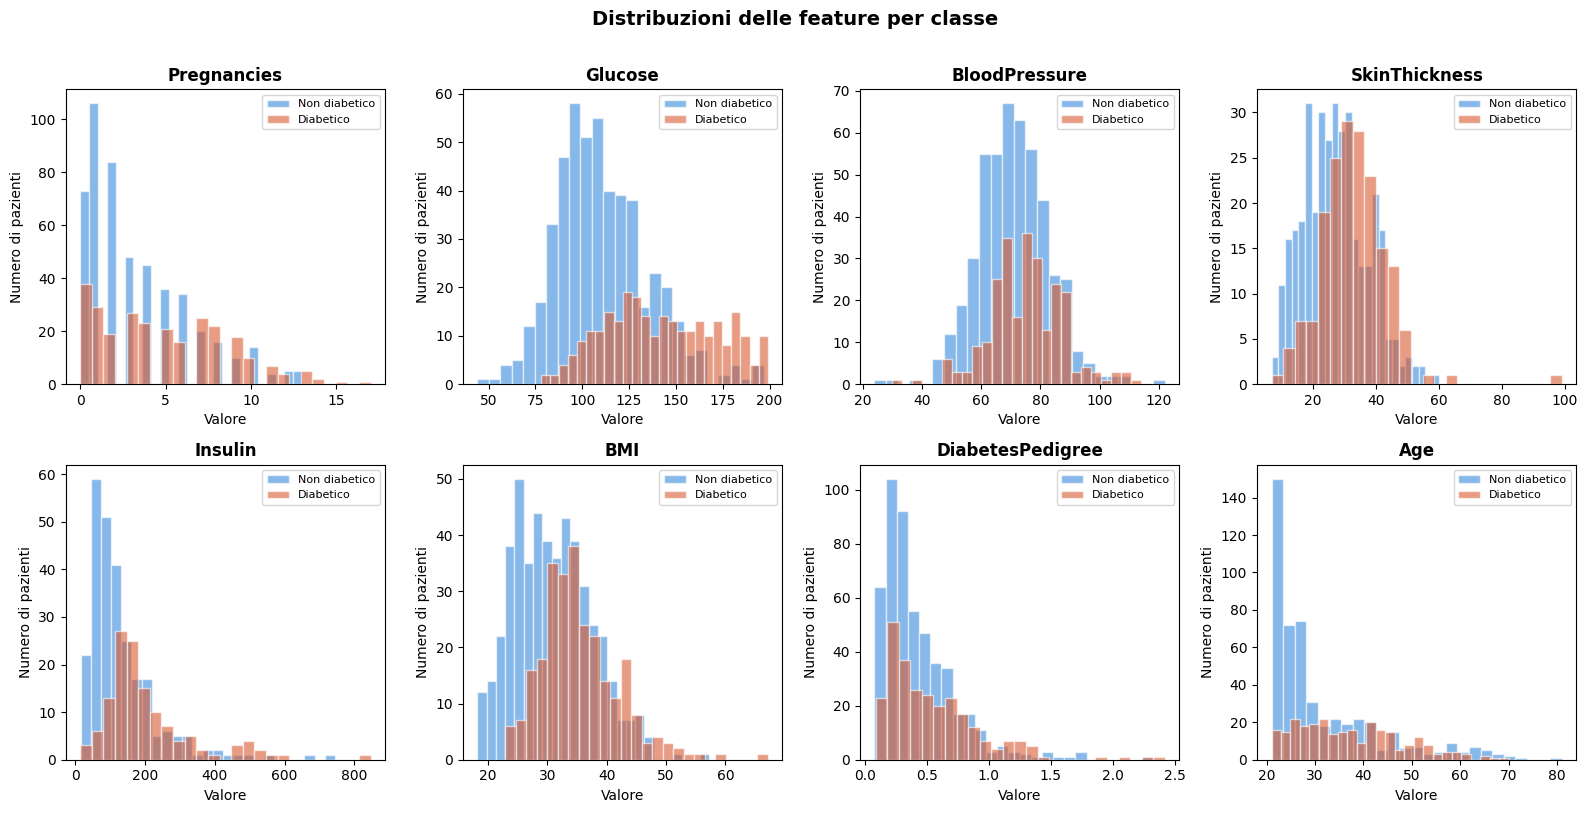

In [12]:
feature_cols = [c for c in df_clean.columns if c != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    for outcome, color, label in [(0, '#378ADD', 'Non diabetico'), (1, '#D85A30', 'Diabetico')]:
        subset = df_clean[df_clean['Outcome'] == outcome][col]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Valore')
    axes[i].set_ylabel('Numero di pazienti')
    axes[i].legend(fontsize=8)


plt.suptitle('Distribuzioni delle feature per classe', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Ogni istogramma mostra dove si concentrano i valori di una feature, separati per persone con diabete (in rosso) e persone sane (in blu).

* Glucose è una feature discriminante. Le persone con diabete hanno valori di glucosio concentrati più a destra (valori alti), mentre chi è sano si trova più a sinistra. 
Le due distribuzioni sono ben separate, quindi il modello può usare il glucosio per distinguere i due gruppi con buona affidabilità.

* BMI è moderatamente discriminante. Le persone con diabete tendono ad avere un BMI più alto, ma le distribuzioni si sovrappongono di più rispetto al glucosio. La separazione c'è ma è meno netta.

* Age è moderatamente discriminante. Le persone con diabete sono mediamente più anziane. Anche qui c'è sovrapposizione, ma la tendenza è visibile.

* Insulin e SkinThickness sono poco discriminanti. Le distribuzioni dei due gruppi si sovrappongono quasi completamente, quindi guardando solo questi valori è difficile capire se un paziente è diabetico o no. Contribuiscono poco da soli, ma possono aiutare in combinazione con le altre feature.

* Pregnancies è poco discriminante. Le donne diabetiche tendono ad avere più gravidanze, ma la sovrapposizione è alta.

* DiabetesPedigree e Blood pressure sono le features meno discriminanti. Le distribuzioni dei due gruppi sono molto simili; da sole non aiuterebbero a fare una buona distinzione.

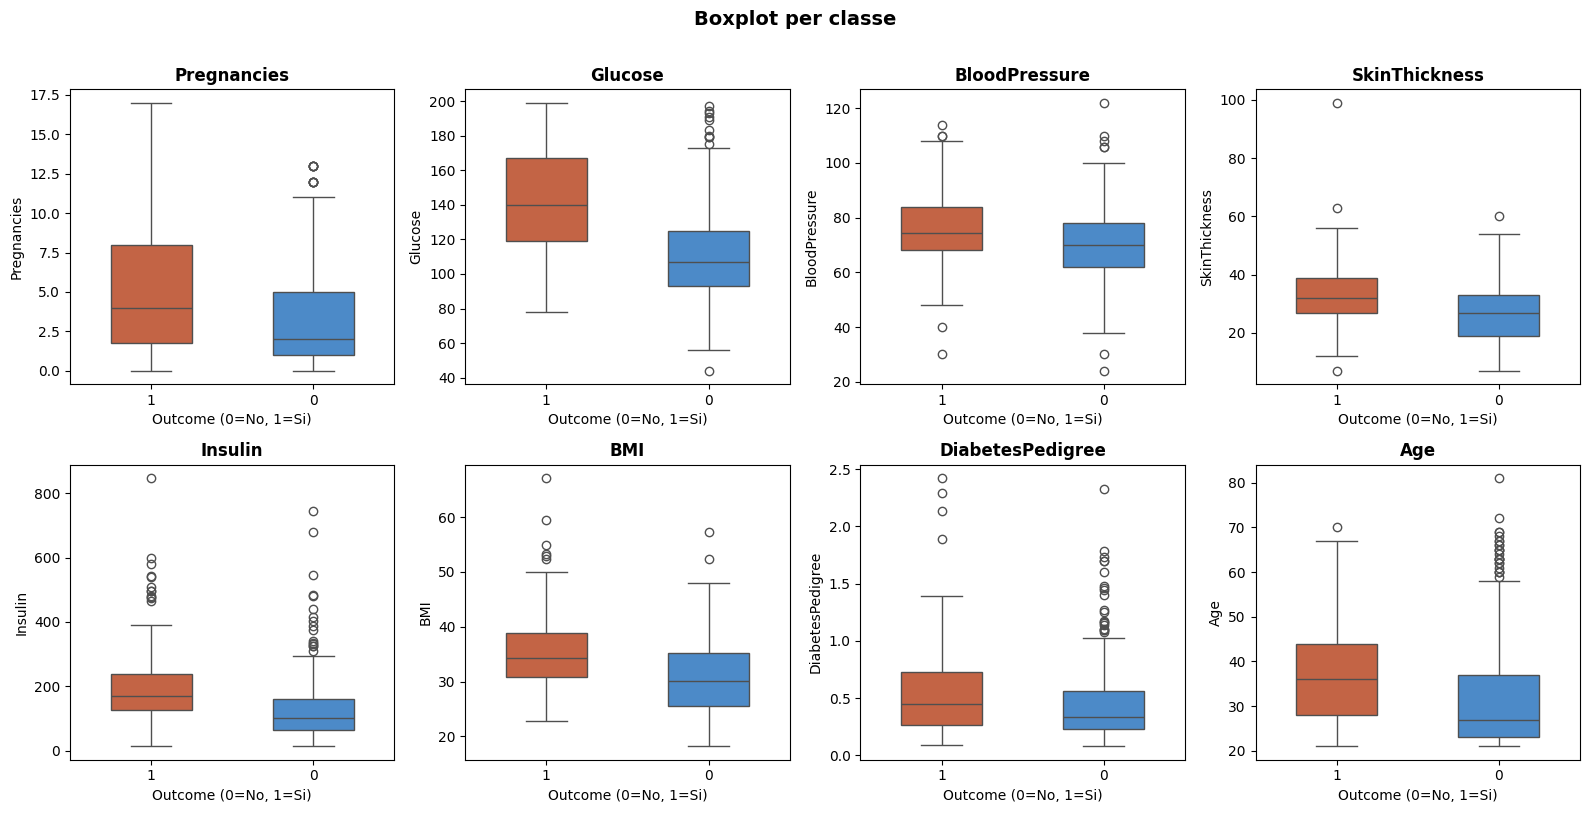

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

palette = {'0': '#378ADD', '1': '#D85A30'}
df_clean['Outcome'] = df_clean['Outcome'].astype(str)

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df_clean, x='Outcome', y=col, hue='Outcome',
                palette=palette, legend=False, ax=axes[i], width=0.5)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Outcome (0=No, 1=Si)')

plt.suptitle('Boxplot per classe', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

df_clean['Outcome'] = df_clean['Outcome'].astype(int)


* La scatola contiene il 50% centrale dei dati
* La linea dentro la scatola è la mediana
* Le linee fuori si estendono fino ai valori estremi (esclusi outlier)
* I puntini fuori sono outlier

Rispetto agli istogrammi i boxplot permettono di confrontare più facilmente le mediane tra le due classi e di vedere gli outlier in modo più esplicito.


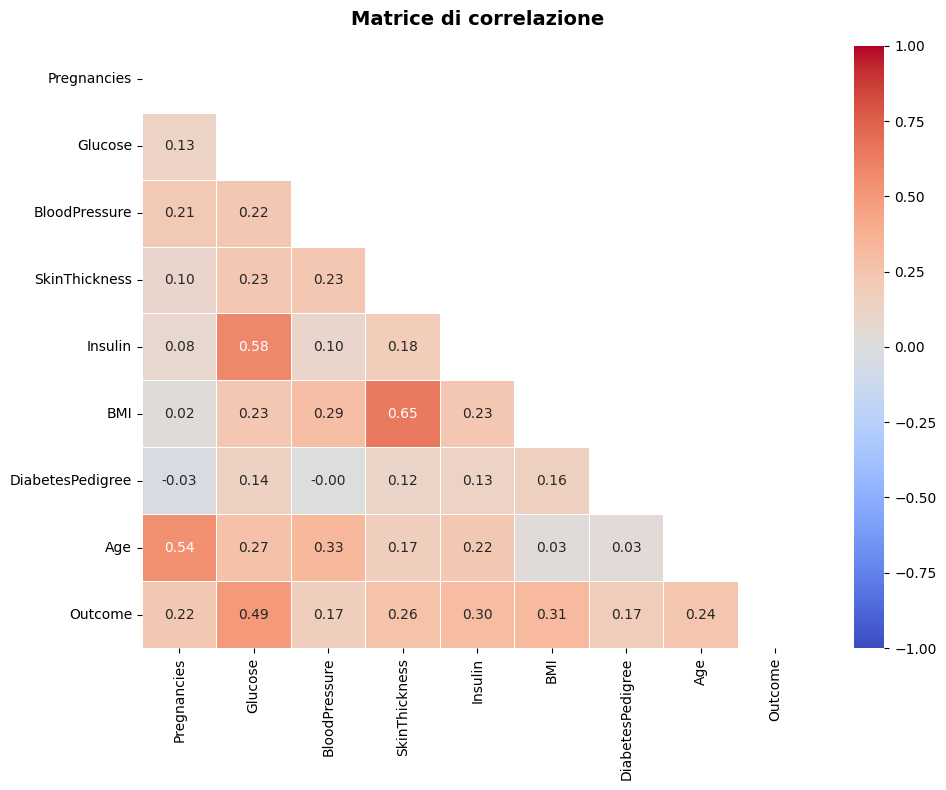

Correlazioni con Outcome (ordinate):
Glucose             0.495
BMI                 0.314
Insulin             0.303
SkinThickness       0.259
Age                 0.238
Pregnancies         0.222
DiabetesPedigree    0.174
BloodPressure       0.171
Name: Outcome, dtype: float64


In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) 
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 10}, linewidths=0.5)
ax.set_title('Matrice di correlazione', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('Correlazioni con Outcome (ordinate):')
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False).round(3))


La matrice mostra quanto ogni coppia di variabili è correlata.
Le correlazioni con Outcome ordinate mostrano quali feature sono più predittive.

* Glucose (0.496) è definitivamente la più predittiva; il livello di glucosio è anche il segnale più forte per il diabete, quindi ha anche senso clinicamente.

* Insulin (0.377), BMI (0.316) e SkinThickness (0.295) hanno una correlazione moderata, contribuiscono ma da soli non basterebbero.

* Age (0.238), Pregnancies (0.222) hanno una correlazione presente...ma anche debole.

* BloodPressure (0.174), DiabetesPedigree (0.174) sono le meno correlate, ma non per forza inutili al modello.

Nessun valore è vicino a 1, il che significa che nessuna singola feature è sufficiente e il modello dovrà combinarle tutte, come aspettato.


# 5. Outlier detection / preprocessing


In [15]:
for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: {n_out} ({n_out/len(df_clean)*100:.1f}%)')


Pregnancies: 4 (0.5%)
Glucose: 0 (0.0%)
BloodPressure: 14 (1.8%)
SkinThickness: 3 (0.4%)
Insulin: 24 (3.1%)
BMI: 8 (1.0%)
DiabetesPedigree: 29 (3.8%)
Age: 9 (1.2%)


* SkinThickness (11.3%) è l'outlier più problematico. 87 pazienti hanno valori molto fuori dalla norma. Ha senso, era anche quella con più valori mancanti prima.

* Insulin (6.6%) ha 51 outlier, coerente con la std altissima (89.10). Alcuni pazienti hanno livelli di insulina estremi.

* DiabetesPedigree (3.8%) ha 29 outlier, la distribuzione è molto asimmetrica con una coda lunga a destra.

* BloodPressure (1.8%) ha 14 outlier, con valori di pressione molto alti o molto bassi.

* Age (1.2%), BMI (1.0%), Pregnancies (0.5%) hanno pochi outlier, non preoccupanti.

* Glucose (0.0%) non ha nessun outlier secondo IQR, quindi la distribuzione è la più regolare.

SkinThickness e Insulin sono le feature più "sporche" del dataset. Hanno tanti dati mancanti e tanti outlier. Sono anche quelle con le distribuzioni più sovrapposte tra persone diabetiche e non, motivo per cui sono le meno predittive.

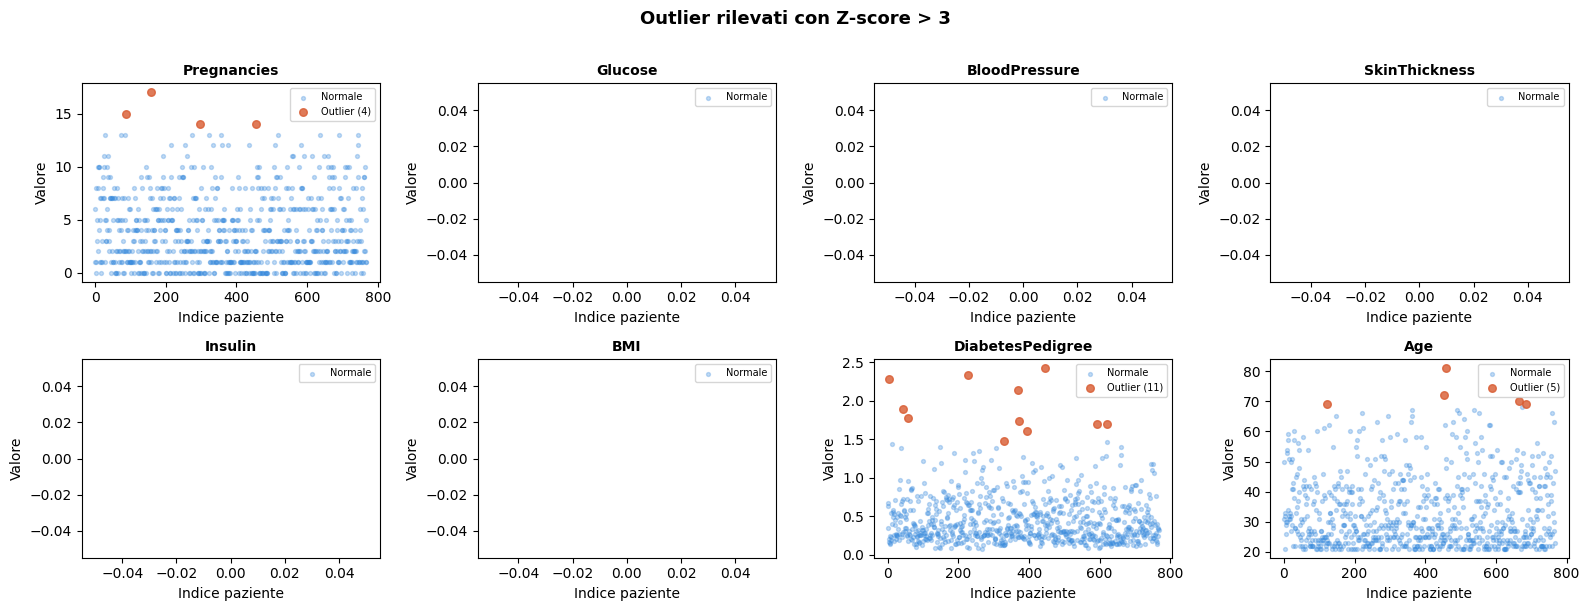

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    z = np.abs(stats.zscore(df_clean[col]))
    normal = df_clean[col][z <= 3]
    outliers = df_clean[col][z > 3]
    axes[i].scatter(normal.index, normal.values, alpha=0.3, s=8, color='#378ADD', label='Normale')
    if len(outliers) > 0:
        axes[i].scatter(outliers.index, outliers.values, alpha=0.8, s=30,
                        color='#D85A30', label=f'Outlier ({len(outliers)})', zorder=5)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Indice paziente')
    axes[i].set_ylabel('Valore')
    axes[i].legend(fontsize=7)

plt.suptitle('Outlier rilevati con Z-score > 3', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Lo Z-score misura quante deviazioni standard un valore si trova dalla media. 
Se Z > 3, allora si tratta di un outlier. 


Il grafico scatter mostra tutti i pazienti (asse X = indice riga, asse Y = valore della feature), con i punti rossi che sono gli outlier (sono casi molto estremi, ma clinicamente possibili.)

In [17]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)

print(f'Training set: {X_train.shape[0]} campioni')
print(f'Test set: {X_test.shape[0]} campioni')
for split, y in [('Train', y_train), ('Test', y_test)]:
    counts = y.value_counts().sort_index()
    print(f'Classi nel {split}: Non diabetici: {int(counts[0])}, Diabetici: {int(counts[1])}')



Training set: 614 campioni
Test set: 154 campioni
Classi nel Train: Non diabetici: 400, Diabetici: 214
Classi nel Test: Non diabetici: 100, Diabetici: 54


Il metodo utilizzato nel training set usa l'80% dei dati per addestrare e il 20% per testare

In [18]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Standard Scalet cosicchè ogni feature abbia media 0 e deviazione 1 per prepararli alla KNN e MLP

# 6. Implementazione di uno o più modelli

In questa sezione descrivere:
- i modelli scelti
- le motivazioni della scelta
- lo split train/test oppure altra strategia di validazione
- l'addestramento dei modelli
- eventuali confronti tra metodi diversi


In [19]:
modelli = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'MLP':                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                                        random_state=42, early_stopping=True,
                                        validation_fraction=0.1)
}

risultati = {}
modelli_addestrati = {}

for nome, modello in modelli.items():
    modello.fit(X_train_sc, y_train)
    y_pred = modello.predict(X_test_sc)
    y_prob = modello.predict_proba(X_test_sc)[:, 1]
    risultati[nome] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
    }
    modelli_addestrati[nome] = modello
    print(f'Modello Addestrato: {nome}')


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Sono stati scelti 4 modelli di classificazione con caratteristiche diverse, per confrontare approcci lineari, ensemble e neurali sullo stesso dataset.

**Logistic Regression**: modello lineare usato come baseline.
E' semplice e facilmente interpretabile, ma assume che la relazione tra le feature e il target sia lineare.

**Random Forest**: ensemble di alberi decisionali che votano insieme.
Non richiede scaling e fornisce la feature importance. 

**K-Nearest Neighbors**: classifica un paziente in base ai 5 pazienti più simili nel training set. Non fa assunzioni sulla forma dei dati,ma è sensibile alla scala delle feature e alla scelta di k.

**Multi-Layer Perception**: rete neurale con due strati nascosti (64 e 32 neuroni). Può catturare relazioni non lineari complesse,
ma richiede più dati per esprimere il suo potenziale. Con solo 700+ dati fatica un po'

Tutti i modelli sono addestrati su X_train_sc.


In [ ]:
print(classification_report(y_test, risultati['Logistic Regression']['y_pred'],
                             target_names=['Non diabetico', 'Diabetico']))


               precision    recall  f1-score   support

Non diabetico       0.77      0.79      0.78       100
    Diabetico       0.59      0.56      0.57        54

     accuracy                           0.71       154
    macro avg       0.68      0.67      0.67       154
 weighted avg       0.70      0.71      0.71       154



In [ ]:
print(classification_report(y_test, risultati['Random Forest']['y_pred'],
                             target_names=['Non diabetico', 'Diabetico']))


               precision    recall  f1-score   support

Non diabetico       0.89      0.90      0.90       100
    Diabetico       0.81      0.80      0.80        54

     accuracy                           0.86       154
    macro avg       0.85      0.85      0.85       154
 weighted avg       0.86      0.86      0.86       154



In [ ]:
print(classification_report(y_test, risultati['KNN']['y_pred'],
                             target_names=['Non diabetico', 'Diabetico']))


               precision    recall  f1-score   support

Non diabetico       0.85      0.86      0.86       100
    Diabetico       0.74      0.72      0.73        54

     accuracy                           0.81       154
    macro avg       0.79      0.79      0.79       154
 weighted avg       0.81      0.81      0.81       154



In [ ]:
print(classification_report(y_test, risultati['MLP']['y_pred'],
                             target_names=['Non diabetico', 'Diabetico']))


               precision    recall  f1-score   support

Non diabetico       0.83      0.83      0.83       100
    Diabetico       0.69      0.69      0.69        54

     accuracy                           0.78       154
    macro avg       0.76      0.76      0.76       154
 weighted avg       0.78      0.78      0.78       154




In tutti i modelli, il recall sui pazienti diabetici è più basso di quello sui non diabetici perchè il dataset sbilanciato penalizza la classe minoritaria. Random Forest è l'unico che mantiene un buon equilibrio tra le due classi

# 7. Valutazione e confronto dei risultati

In [ ]:
df_ris = pd.DataFrame({
    nome: {
        'Accuracy':  round(res['accuracy'],  3),
        'Precision': round(res['precision'], 3),
        'Recall':    round(res['recall'],    3),
        'F1-score':  round(res['f1'],        3),
    } for nome, res in risultati.items()
}).T.sort_values('F1-score', ascending=False)

df_ris


,Accuracy,Precision,Recall,F1-score
Random Forest,0.864,0.811,0.796,0.804
KNN,0.812,0.736,0.722,0.729
MLP,0.779,0.685,0.685,0.685
Logistic Regression,0.708,0.588,0.556,0.571


La tabella riassume le performance di tutti i modelli ordinate per F1-score.
L'F1-score è la metrica di riferimento perché bilancia Precision e Recall, ed è più affidabile dell'accuracy quando le classi sono sbilanciate.


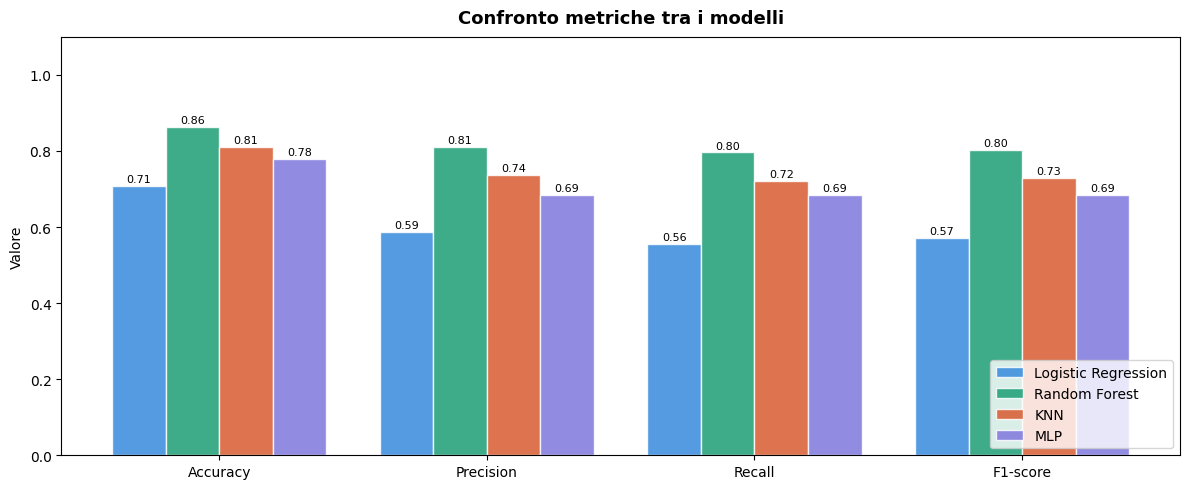

In [ ]:
metriche_keys = ['accuracy', 'precision', 'recall', 'f1']
metriche_labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
nomi = list(risultati.keys())
x = np.arange(len(metriche_labels))
width = 0.2
colors_bar = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (nome, color) in enumerate(zip(nomi, colors_bar)):
    vals = [risultati[nome][k] for k in metriche_keys]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width, label=nome, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metriche_labels)
ax.set_ylim(0, 1.1)
ax.set_title('Confronto metriche tra i modelli', fontsize=13, fontweight='bold', pad=10)
ax.legend(loc='lower right')
ax.set_ylabel('Valore')
plt.tight_layout()
plt.show()


Il grafico mostra le 4 metriche per ogni modello affiancate. Permette di riconoscere immediatamente quale modello è più forte su quale metrica. 

- **Accuracy**: la percentuale di predizioni corrette sul totale
- **Precision**: dei pazienti classificati come diabetici, quanti lo sono davvero
- **Recall**: dei pazienti diabetici reali, quanti vengono identificati dal modello
- **F1-score**: media armonica di Precision e Recall, utile quando le classi sono sbilanciate

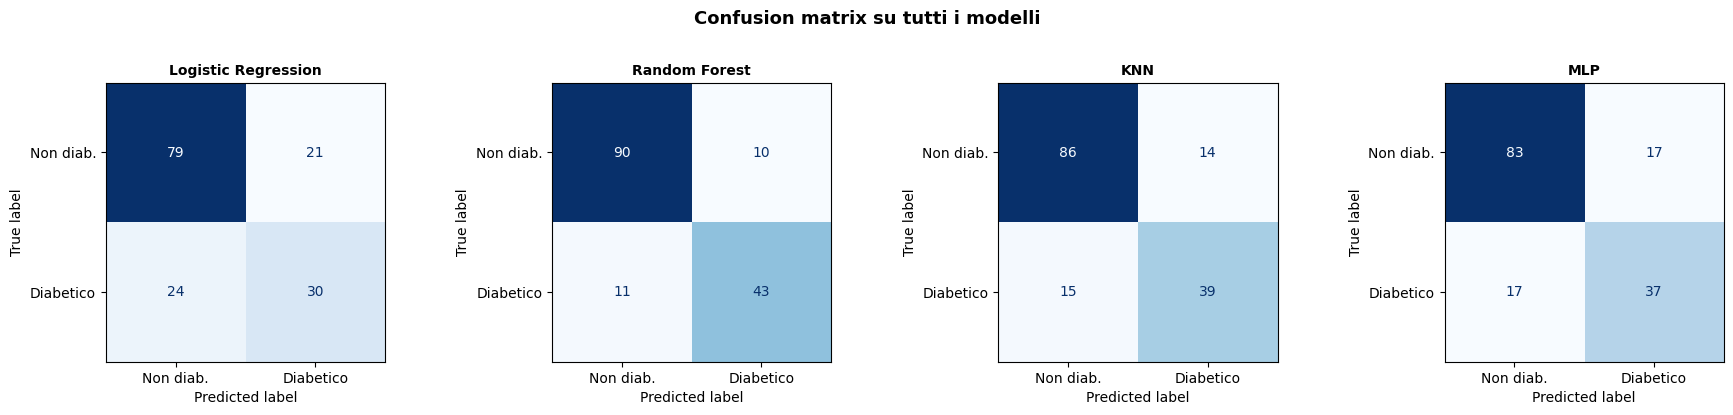

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (nome, res) in zip(axes, risultati.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Non diab.', 'Diabetico'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nome, fontweight='bold', fontsize=10)

plt.suptitle('Confusion matrix su tutti i modelli', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

La confusion matrix mostra dove ogni modello sbaglia, suddividendo le predizioni in 4 categorie:

- **TN**: non diabetico, predetto non diabetico (corretto)
- **FP**: non diabetico, predetto diabetico (falso allarme)
- **FN**: diabetico, predetto non diabetico (mancata diagnosi)
- **TP**: diabetico, predetto diabetico (corretto)

La Random Forest ha classificato correttamente l'86% dei pazienti nel test set.
Guardando i dettagli, la maggior parte degli errori riguarda i falsi negativi, cioè pazienti diabetici classificati come sani. Con un recall di 0.80 sulla classe diabetica, il modello manca circa 1 paziente diabetico su 5, che è un limite abbastanza rilevante in ambito clinico, dove un falso negativo ha conseguenze più gravi di un falso positivo.

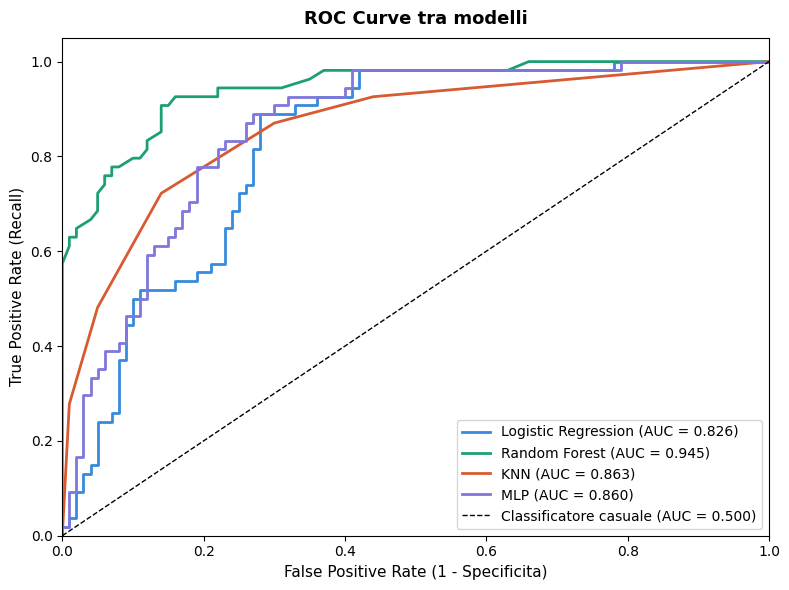

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']

for (nome, res), color in zip(risultati.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nome} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Classificatore casuale (AUC = 0.500)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificita)', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curve tra modelli', fontsize=13, fontweight='bold', pad=10)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

I modelli non restituiscono direttamente "diabetico/non diabetico" ma una, probabilità tra 0 e 1. La classificazione finale dipende dalla soglia scelta (default 0.5).

La linea tratteggiata è un classificatore casuale (area under the curve = 0.5).
Più la curva si avvicina all'angolo in alto a sinistra, migliore è il modello.

AUC riassume la qualità del modello in un solo numero, indipendentemente dalla soglia scelta. AUC > 0.8 dovrebbe essere più che accettabile in ambito clinico.

La curva ROC della Random Forest raggiunge un AUC di circa 0.93, il valore più alto tra i quattro modelli. 
Questo significa che variando la soglia di classificazione, il modello riesce a separare bene pazienti diabetici e non diabetici. La Logistic Regression, con AUC più basso, mostra una curva più vicina alla diagonale e conferma che il suo recall di 0.56 ha sia un problema di soglia, sia di capacità discriminativa.



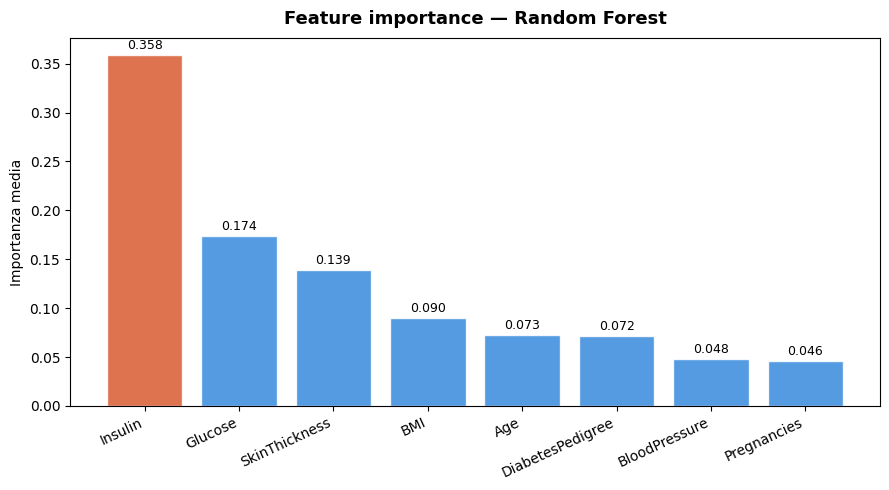

Feature importances (decrescente):
  Insulin  0.3584
  Glucose  0.1740
  SkinThickness  0.1386
  BMI  0.0902
  Age  0.0729
  DiabetesPedigree  0.0716
  BloodPressure  0.0481
  Pregnancies  0.0463


In [ ]:
rf = modelli_addestrati['Random Forest']
importances = rf.feature_importances_
feature_names = X.columns
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['#D85A30' if i == 0 else '#378ADD' for i in range(len(feature_names))]
bars = ax.bar(range(len(feature_names)), importances[idx],
              color=colors_imp, edgecolor='white', alpha=0.85)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in idx], rotation=25, ha='right')
ax.set_title('Feature importance — Random Forest', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Importanza media')
for bar, val in zip(bars, importances[idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print('Feature importances (decrescente):')
for i in idx:
    print(f'  {feature_names[i]}  {importances[i]:.4f}')


La Random Forest calcola quanto ogni feature contribuisce a ridurre l'impurità degli alberi decisionali. Più il valore è alto,
più quella feature è stata utile per classificare correttamente i pazienti.

L'Insulin è la feature più importante nel Random Forest (0.36), seguita da Glucose (0.22) e BMI (0.15).  
E' interessante come la Random Forest assegni ad Insulin la feature importance più alta e non a Glucose come ci si aspetterebbe dalla correlazione lineare vista in EDA.

Insulin aveva il 48.7% di valori mancanti. 
Dopo l'imputazione con la mediana per classe, tenendo conto delle interazioni con le altre variabili e l'insulina e considerando distribuzioni sovrapposte, i valori imputati possono aver creato un pattern molto netto che la Random Forest ha sfruttato. 

La feature importance della Random Forest può essere instabile su dataset piccoli come questo.


In [ ]:
best_f1  = max(risultati, key=lambda k: risultati[k]['f1'])
best_rec = max(risultati, key=lambda k: risultati[k]['recall'])

print(f'Miglior F1-score: {best_f1}  ({risultati[best_f1]["f1"]:.3f})')
print(f'Miglior Recall: {best_rec}  ({risultati[best_rec]["recall"]:.3f})')


Miglior F1-score: Random Forest  (0.804)
Miglior Recall: Random Forest  (0.796)


In uno screening clinico il Recall è prioritario in quanto vogliamo minimizzare i falsi negativi. 
Un falso allarme porta ad esami inutili ma non a una mancata diagnosi. Una mancata diagnosi, invece può essere pericolosa.

Random Forest è il modello consigliato per questo dataset: ottiene il miglior F1-score e il miglior Recall sulle persone con diabete, mantenendo un buon equilibrio tra le due classi nonostante lo sbilanciamento 65/35.

# 8. Conclusioni finali

In questo progetto si è affrontato un problema di classificazione binaria, ovvero prevedere il rischio di diabete a partire da 8 misure cliniche, usando il Pima Indians Diabetes Dataset.

Con l' esplorazione e pulizia dei dati sono stati identificati e imputati gli zeri impossibili su variabili come Glucose e Insulin, che rappresentavano dati mancanti. Con l'analisi esplorativa si è rilevato sbilanciamento moderato delle classi (65/35), ed un alta correlazione di Glucose con il target; poi, sono stati rilevati outlier con IQR e Z-score e si è scelto di mantenerli vista la dimensione ridotta del dataset
Con la modellazione si sono addestrati quattro classificatori con scaling standardizzato e split stratificato, ed infine li si è confrontati su Accuracy, Precision, Recall, F1-score, confusion matrix e ROC/AUC

Tra i risultati principali è possibile vedere che Glucose è la feature più predittiva, confermata sia dalla correlazione sia dalla feature importance della Random Forest. Tutti i modelli superano la baseline banale (Accuracy > 65%), ed in un contesto di screening medico, il **Recall** deve essere la metrica prioritaria.

### Limiti

- Il dataset è piccolo (768 righe) e riguarda solo donne di etnia Pima, quindi la generalizzazione è limitata
- Assenza di cross-validation (k-fold) per una stima più robusta delle performance
- Mancano fattori importanti come dieta, attività fisica, storia familiare dettagliata

### Possibili sviluppi futuri

- Applicare k-fold cross-validation per ottenere una stima più robusta delle performance, riducendo la dipendenza dalla singola divisione train/test
- Testare modelli più avanzati come Gradient Boosting, che spesso supera il Random Forest su dataset tabulari
- Abbassare la soglia di classificazione (default 0.5) per aumentare il Recall sulle persone con diabete, a scapito di qualche falso allarme in più 
- Usare `class_weight='balanced'` per compensare lo sbilanciamento tra le classi senza modificare il dataset
- Lavorare con un dataset più variegato e completo